#real data

heatmap calculation for overlap in volumetric


Debug: Column names for roi_coordinates_B-cell_infiltration.csv: ['Model', 'ROI_ID', 'x', 'y', 'z']
First few rows:
  Model  ROI_ID     x     y   z
0   GAT       1  8064  2928  28
1   GAT       2  4104  1456  88
2   GAT       3  6344  2656  86
3   GAT       4  1368  2232  76
4   GAT       5  2600  1168  76

GAT data types:
Model     object
ROI_ID     int64
x          int64
y          int64
z          int64
dtype: object
Sample GAT row:
Model      GAT
ROI_ID       1
x         8064
y         2928
z           28
Name: 0, dtype: object

DETAILED ANALYSIS: Person 6 - Inflammatory_zone

GAT points (5 points):
  ROI_ID 1: x=464, y=384, z=45
  ROI_ID 2: x=784, y=1024, z=84
  ROI_ID 3: x=8880, y=3264, z=38
  ROI_ID 4: x=2480, y=2032, z=130
  ROI_ID 5: x=3328, y=2168, z=80

Person 6 points (5 points):
  ROI_ID 1: x=535, y=952, z=53
  ROI_ID 2: x=3903, y=2224, z=66
  ROI_ID 3: x=8538, y=3251, z=99
  ROI_ID 4: x=6265, y=3435, z=147
  ROI_ID 5: x=2942, y=2055, z=161

Detailed distance calculations

C:\Users\hosse\AppData\Local\Temp\ipykernel_43612\4167564319.py:511: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.97])


Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\errorbar_grid_all_topics_euclidean_min.png


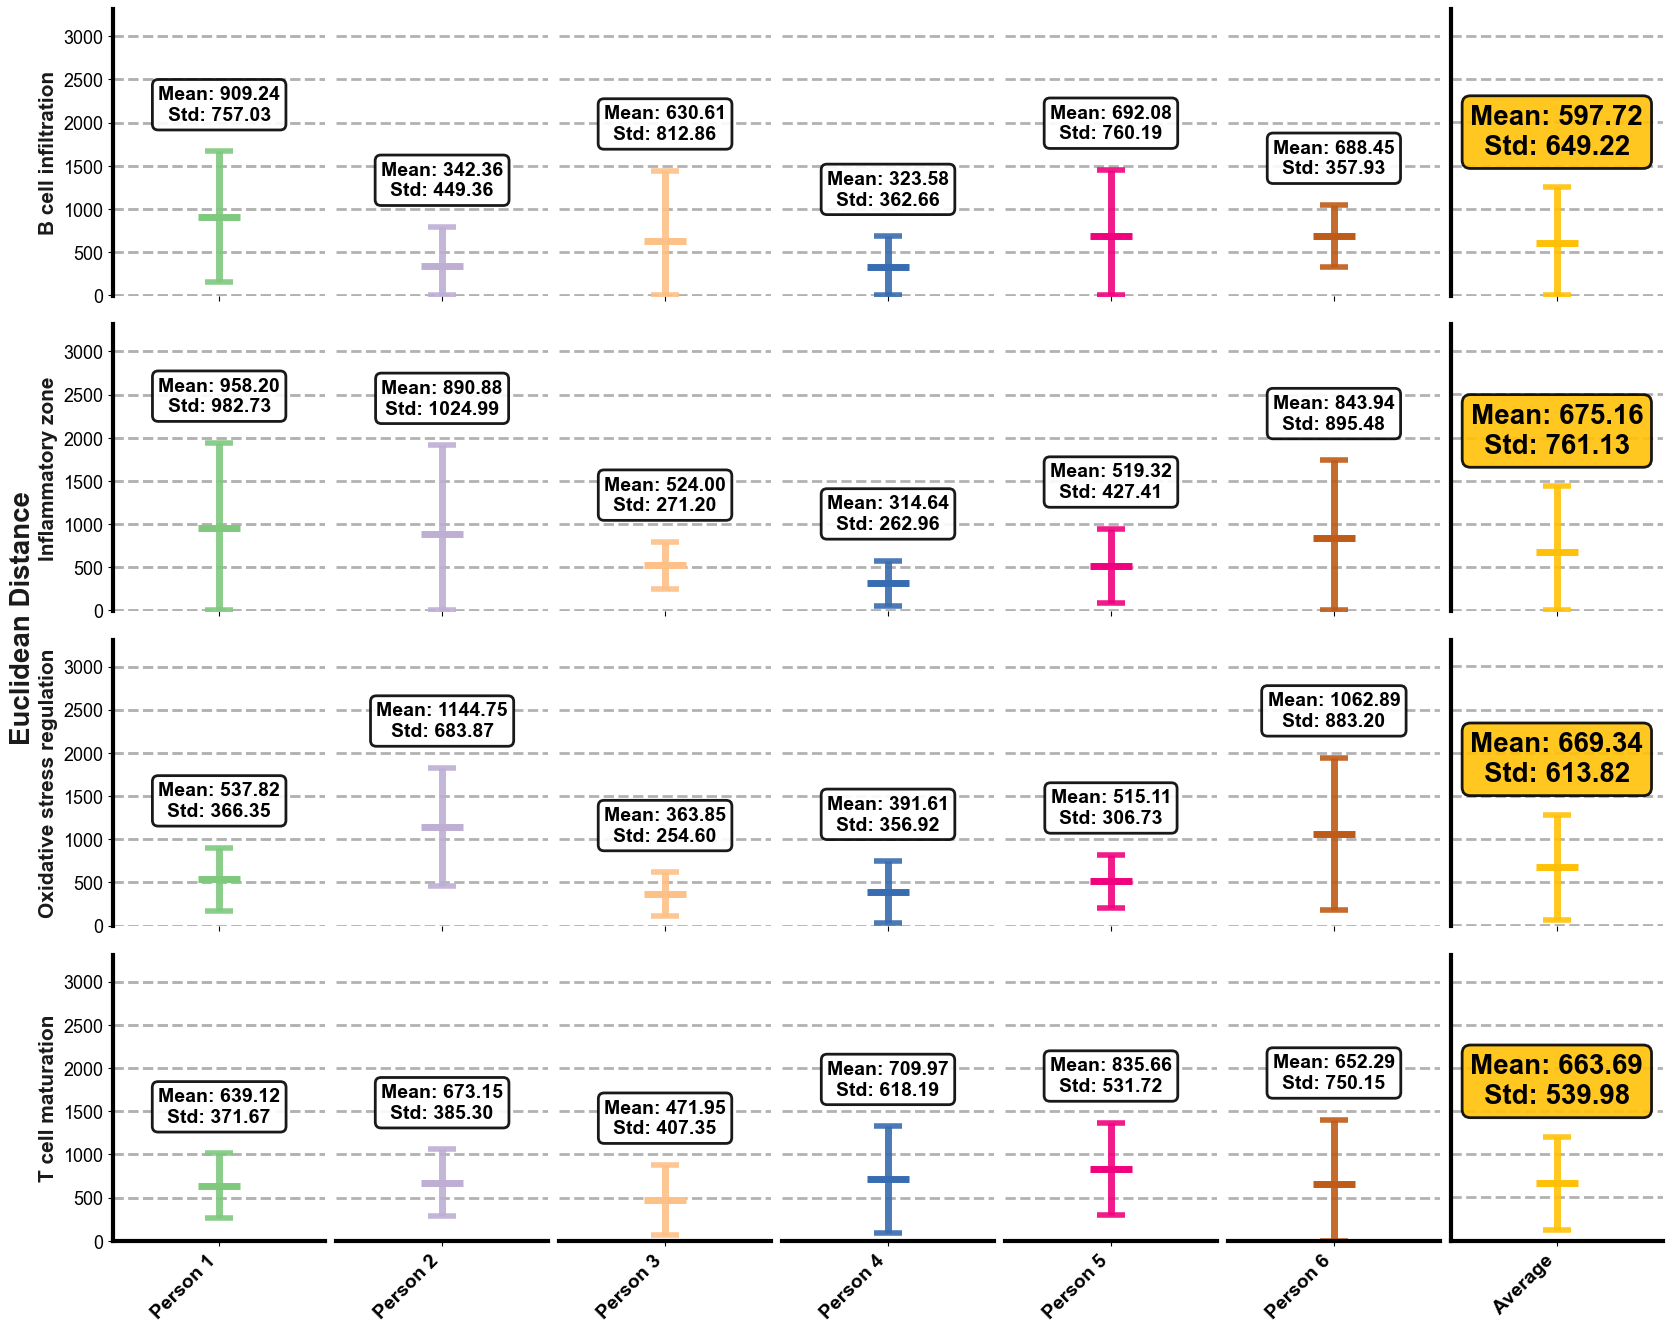

Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\heatmap_euclidean_distance_min.png


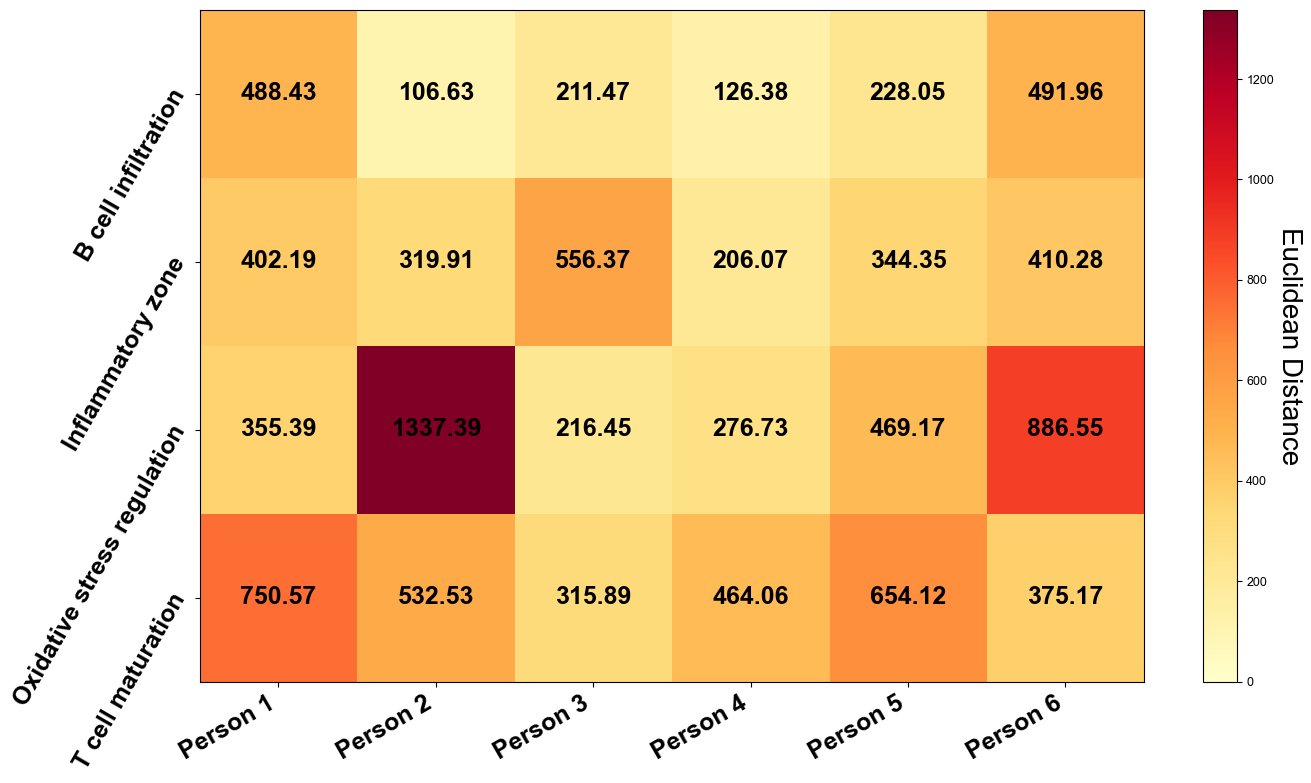

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math

base_dir = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth")
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

def euclidean_distance_3d(p1, p2):
    """Calculate 3D Euclidean distance between two points"""
    return math.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

def calc_min_euclidean_distances(gat_data, person_data):
    """For each person point, find minimum distance to any GAT point"""
    if len(gat_data) == 0 or len(person_data) == 0: 
        return []
    
    # Create list of all GAT points - ensure numeric conversion
    gat_points = []
    for _, row in gat_data.iterrows():
        x = float(row['x'])
        y = float(row['y'])
        z = float(row['z'])
        gat_points.append((x, y, z))
    
    min_distances = []
    
    # For each person point, calculate distance to all GAT points and find minimum
    for idx, person_row in person_data.iterrows():
        # Ensure numeric conversion
        px = float(person_row['x'])
        py = float(person_row['y'])
        pz = float(person_row['z'])
        person_point = (px, py, pz)
        
        # Calculate distance from this person point to all GAT points
        distances = []
        for gat_point in gat_points:
            dist = euclidean_distance_3d(person_point, gat_point)
            distances.append(dist)
            # Check for exactly zero distance (shouldn't happen unless points are identical)
            if dist < 1e-10:  # Very small threshold for floating point comparison
                print(f"  DEBUG: Found very small distance {dist:.12f} between person point {person_point} and GAT point {gat_point}")
        
        # Find and store the minimum distance
        if len(distances) == 0:
            print(f"  WARNING: No distances calculated for person point {person_point}")
            continue
            
        min_dist = min(distances)
        
        # Additional check
        if min_dist < 0.001:
            print(f"  DEBUG: Very small minimum distance {min_dist:.12f} for person point {person_point}")
            print(f"    All distances to GAT points: {[f'{d:.6f}' for d in distances]}")
            print(f"    GAT points: {gat_points}")
        
        min_distances.append(min_dist)
    
    return min_distances

# Process CSV files
results = {}
all_distances = {f'Person {i}': [] for i in range(1, 7)}

for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path)
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    # Debug: Print column names (only for first file)
    if csv_filename == csv_files[0]:
        print(f"\nDebug: Column names for {csv_filename}: {df.columns.tolist()}")
        print(f"First few rows:\n{df.head()}")
    
    gat_data = df[df.iloc[:, 0] == 'GAT'].copy().sort_values(by='ROI_ID').reset_index(drop=True)
    
    # Debug: Verify data types (only for first file)
    if csv_filename == csv_files[0] and len(gat_data) > 0:
        print(f"\nGAT data types:\n{gat_data.dtypes}")
        print(f"Sample GAT row:\n{gat_data.iloc[0]}")
    
    results[sheet_name] = {}
    
    for person_num in range(1, 7):
        person_name = f'Person {person_num}'
        person_data = df[df.iloc[:, 0] == person_name].copy().sort_values(by='ROI_ID').reset_index(drop=True)
        
        if len(person_data) == 0:
            continue
        
        distances = calc_min_euclidean_distances(gat_data, person_data)
        
        if len(distances) > 0:
            min_dist = np.min(distances)
            mean_dist = np.mean(distances)
            
            # Check for zero or very small distances
            if min_dist < 0.001:
                print(f"WARNING: {sheet_name} - {person_name} has very small minimum distance: {min_dist:.6f}")
                print(f"  All distances: {[f'{d:.6f}' for d in distances]}")
                print(f"  GAT points: {[(row['x'], row['y'], row['z']) for _, row in gat_data.iterrows()]}")
                print(f"  Person points: {[(row['x'], row['y'], row['z']) for _, row in person_data.iterrows()]}")
            
            results[sheet_name][person_name] = {
                'distances': distances,
                'mean': mean_dist,
                'median': np.median(distances),
                'std': np.std(distances),
                'min': min_dist,
                'max': np.max(distances)
            }
            all_distances[person_name].extend(distances)

# Detailed analysis for Person 6 and Inflammatory_zone
print("\n" + "="*80)
print("DETAILED ANALYSIS: Person 6 - Inflammatory_zone")
print("="*80)

csv_path_inflam = base_dir / 'roi_coordinates_Inflammatory_zone.csv'
if csv_path_inflam.exists():
    df_inflam = pd.read_csv(csv_path_inflam)
    gat_data_inflam = df_inflam[df_inflam.iloc[:, 0] == 'GAT'].copy().sort_values(by='ROI_ID').reset_index(drop=True)
    person6_data_inflam = df_inflam[df_inflam.iloc[:, 0] == 'Person 6'].copy().sort_values(by='ROI_ID').reset_index(drop=True)
    
    print(f"\nGAT points ({len(gat_data_inflam)} points):")
    for idx, row in gat_data_inflam.iterrows():
        print(f"  ROI_ID {row['ROI_ID']}: x={row['x']}, y={row['y']}, z={row['z']}")
    
    print(f"\nPerson 6 points ({len(person6_data_inflam)} points):")
    for idx, row in person6_data_inflam.iterrows():
        print(f"  ROI_ID {row['ROI_ID']}: x={row['x']}, y={row['y']}, z={row['z']}")
    
    # Calculate distances for each Person 6 point
    print(f"\nDetailed distance calculations:")
    all_min_distances_p6 = []
    for idx, person_row in person6_data_inflam.iterrows():
        px = float(person_row['x'])
        py = float(person_row['y'])
        pz = float(person_row['z'])
        person_point = (px, py, pz)
        
        print(f"\n  Person 6, ROI_ID {person_row['ROI_ID']}: ({px}, {py}, {pz})")
        
        distances_to_all_gat = []
        for gat_idx, gat_row in gat_data_inflam.iterrows():
            gx = float(gat_row['x'])
            gy = float(gat_row['y'])
            gz = float(gat_row['z'])
            gat_point = (gx, gy, gz)
            
            dist = euclidean_distance_3d(person_point, gat_point)
            distances_to_all_gat.append(dist)
            print(f"    Distance to GAT ROI_ID {gat_row['ROI_ID']} ({gx}, {gy}, {gz}): {dist:.6f}")
        
        min_dist = min(distances_to_all_gat)
        max_dist = max(distances_to_all_gat)
        all_min_distances_p6.append(min_dist)
        
        print(f"    ---> MINIMUM distance: {min_dist:.6f}")
        print(f"    ---> MAXIMUM distance: {max_dist:.6f}")
    
    print(f"\n" + "-"*80)
    print(f"SUMMARY for Person 6 - Inflammatory_zone:")
    print(f"  All minimum distances: {[f'{d:.6f}' for d in all_min_distances_p6]}")
    print(f"  Overall MINIMUM: {min(all_min_distances_p6):.6f}")
    print(f"  Overall MAXIMUM: {max(all_min_distances_p6):.6f}")
    print(f"  Mean: {np.mean(all_min_distances_p6):.6f}")
    print(f"  Median: {np.median(all_min_distances_p6):.6f}")
    print(f"  Std: {np.std(all_min_distances_p6):.6f}")
    
    # Check if this matches the results dictionary
    if 'Inflammatory_zone' in results and 'Person 6' in results['Inflammatory_zone']:
        stats = results['Inflammatory_zone']['Person 6']
        print(f"\nFrom results dictionary:")
        print(f"  Min: {stats['min']:.6f}")
        print(f"  Max: {stats['max']:.6f}")
        print(f"  Mean: {stats['mean']:.6f}")
        if abs(min(all_min_distances_p6) - stats['min']) > 0.001:
            print(f"  *** MISMATCH in MIN: calculated={min(all_min_distances_p6):.6f}, dictionary={stats['min']:.6f}")
        if abs(max(all_min_distances_p6) - stats['max']) > 0.001:
            print(f"  *** MISMATCH in MAX: calculated={max(all_min_distances_p6):.6f}, dictionary={stats['max']:.6f}")
    
print("="*80)

# Print detailed debug information for Person 3 and Person 6
print("="*60)
print("Debug: Detailed distance calculations for Person 3 and Person 6")
print("="*60)
for csv_filename in csv_files:  # All files
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path)
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    gat_data = df[df.iloc[:, 0] == 'GAT'].copy().sort_values(by='ROI_ID').reset_index(drop=True)
    
    # Check Person 3 and Person 6 specifically
    for person_check in ['Person 3', 'Person 6']:
        person_data = df[df.iloc[:, 0] == person_check].copy().sort_values(by='ROI_ID').reset_index(drop=True)
        if len(person_data) == 0:
            continue
            
        print(f"\n{sheet_name} - {person_check}:")
        print(f"GAT points:")
        for idx, row in gat_data.iterrows():
            print(f"  ROI_ID {row['ROI_ID']}: ({row['x']}, {row['y']}, {row['z']})")
        
        print(f"\n{person_check} points:")
        for idx, row in person_data.iterrows():
            print(f"  ROI_ID {row['ROI_ID']}: ({row['x']}, {row['y']}, {row['z']})")
        
        # Calculate distances for all person points
        print(f"\nDetailed calculations for {person_check}:")
        all_min_distances = []
        for p_idx, person_row in person_data.iterrows():
            person_point = (float(person_row['x']), float(person_row['y']), float(person_row['z']))
            print(f"  Person ROI_ID {person_row['ROI_ID']} point: {person_point}")
            distances_to_gat = []
            for idx, gat_row in gat_data.iterrows():
                gat_point = (float(gat_row['x']), float(gat_row['y']), float(gat_row['z']))
                dist = euclidean_distance_3d(person_point, gat_point)
                distances_to_gat.append(dist)
                print(f"    Distance to GAT ROI_ID {gat_row['ROI_ID']} {gat_point}: {dist:.6f}")
            min_dist = min(distances_to_gat)
            all_min_distances.append(min_dist)
            print(f"    MINIMUM distance: {min_dist:.6f}")
            print()
        
        if sheet_name in results and person_check in results[sheet_name]:
            dists = results[sheet_name][person_check]['distances']
            print(f"Results summary from calculation:")
            print(f"  Number of distances: {len(dists)}")
            print(f"  All distances: {[f'{d:.6f}' for d in dists]}")
            print(f"  Mean: {results[sheet_name][person_check]['mean']:.6f}")
            print(f"  Min: {results[sheet_name][person_check]['min']:.6f}")
            print(f"  Max: {results[sheet_name][person_check]['max']:.6f}")
            
            # Compare with manual calculation
            print(f"Manual calculation distances: {[f'{d:.6f}' for d in all_min_distances]}")
            if len(dists) == len(all_min_distances):
                for i, (calc_dist, manual_dist) in enumerate(zip(dists, all_min_distances)):
                    if abs(calc_dist - manual_dist) > 0.01:
                        print(f"  WARNING: Mismatch at index {i}: calculated={calc_dist:.6f}, manual={manual_dist:.6f}")
print("="*60)

# Print summary for all results to verify calculations
print("\n" + "="*60)
print("Summary of all calculated distances (ORIGINAL VALUES - NO DIVISION):")
print("="*60)
zero_count = 0
for sheet_name in sorted(results.keys()):
    print(f"\n{sheet_name}:")
    for person_name in sorted(results[sheet_name].keys()):
        stats = results[sheet_name][person_name]
        mean_before = stats['mean']
        min_before = stats['min']
        # Note: No division applied - showing original values
        mean_after = mean_before  # Same as original
        min_after = min_before  # Same as original
        
        # Check for zero or suspiciously small values
        if min_before < 0.001:
            print(f"  *** {person_name}: Mean={mean_before:.6f}, "
                  f"Min={min_before:.6f} (ZERO/SUSPICIOUS!), Max={stats['max']:.2f}, Count={len(stats['distances'])}")
            print(f"      All distances: {[f'{d:.6f}' for d in stats['distances']]}")
            zero_count += 1
        else:
            print(f"  {person_name}: Mean={mean_before:.2f}, "
                  f"Min={min_before:.2f}, Max={stats['max']:.2f}, Count={len(stats['distances'])}")
if zero_count > 0:
    print(f"\n*** WARNING: Found {zero_count} cases with zero or suspiciously small minimum distances!")
else:
    print(f"\n✓ All minimum distances are non-zero (>= 0.001)")
print("="*60)

# Print MIN and MAX for each person and microenvironment in a clear format
print("\n" + "="*80)
print("MIN and MAX Euclidean Distances for Each Person and Microenvironment")
print("="*80)
print("\nFormat: MIN | MAX (both in original units, before division by 16)")
print("-"*80)

for sheet_name in sorted(results.keys()):
    print(f"\n{sheet_name.replace('_', ' ').replace('-', ' ').title()}:")
    print(f"  {'Person':<12} {'MIN':<18} {'MAX':<18}")
    print(f"  {'-'*12} {'-'*18} {'-'*18}")
    for person_name in sorted(results[sheet_name].keys()):
        stats = results[sheet_name][person_name]
        min_val = stats['min']
        max_val = stats['max']
        print(f"  {person_name:<12} {min_val:>17.2f} {max_val:>17.2f}")

print("\n" + "="*80)

person_names = [f'Person {i}' for i in range(1, 7)]
# Better color palette - more vibrant and distinct
person_colors = ['#7fc97f', '#beaed4', '#fdc086', '#386cb0', '#f0027f', '#bf5b17']
topics_list = list(results.keys())

# Set better font settings
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14

# Calculate max distance for x-axis limits (no division - use original values)
max_distance = 0
for sheet_name in topics_list:
    for person_name in person_names:
        if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
            max_distance = max(max_distance, results[sheet_name][person_name]['max'])
x_max = max_distance * 1.1 if max_distance > 0 else 3000

# Debug: Print max values for verification
print(f"\nDebug: max_distance = {max_distance:.2f}, x_max (after * 1.1) = {x_max:.2f}")
print(f"Using original values (no division)")

if len(topics_list) > 0:
    # Grid: rows = topics (microenvironments), columns = persons + average
    num_topics = len(topics_list)
    num_cols = len(person_names) + 1  # +1 for average column
    fig = plt.figure(figsize=(20, 4 * num_topics))
    gs = fig.add_gridspec(num_topics, num_cols, hspace=0.1, wspace=0.05)  # Reduced hspace and wspace for closer spacing

    for row_idx, sheet_name in enumerate(topics_list):
        all_topic_distances = []
        
        # Calculate mean for this microenvironment (for horizontal dash line)
        microenvironment_means = []
        for person_name in person_names:
            if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
                microenvironment_means.append(results[sheet_name][person_name]['mean'])  # No division
        microenvironment_mean = np.mean(microenvironment_means) if len(microenvironment_means) > 0 else 0
        
        # Plot each person in columns
        for col_idx, person_name in enumerate(person_names):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            
            if person_name in results[sheet_name]:
                distances = results[sheet_name][person_name]['distances']
                if len(distances) > 0:
                    all_topic_distances.extend(distances)
                    stats = results[sheet_name][person_name]
                    # Use original values (no division) - using mean
                    mean_val = stats['mean']
                    std_val = stats['std']
                    
                    # Debug print for all values going to plot
                    if sheet_name == 'Inflammatory_zone' and person_name == 'Person 6':
                        print(f"\nDEBUG PLOT VALUES - {sheet_name} - {person_name}:")
                        print(f"  Original stats - mean: {stats['mean']:.6f}, median: {stats['median']:.6f}, std: {stats['std']:.6f}, min: {stats['min']:.6f}, max: {stats['max']:.6f}")
                        print(f"  Using original values - mean_val: {mean_val:.6f}, std_val: {std_val:.6f}")
                        print(f"  *** ACTUAL MINIMUM: {stats['min']:.6f} (NOT ZERO!)")
                        print(f"  *** ACTUAL MAXIMUM: {stats['max']:.6f}")
                        print(f"  Note: Error bar may reach zero when std > mean, but actual min distance is {stats['min']:.6f}")
                    
                    # Create error bar plot (vertical, similar to inter-rater plot)
                    x_pos = 0.5
                    color = person_colors[col_idx]
                    
                    # Error bar (vertical line with caps) - thicker lines
                    # Limit error bar to minimum 0 (mean - std cannot be negative)
                    # yerr_lower should be the distance from mean to (mean - std), but not exceed mean itself
                    # So if std > mean, yerr_lower = mean, otherwise yerr_lower = std
                    yerr_lower = min(std_val, mean_val)  # Ensure error bar doesn't go below 0
                    
                    # Debug: Print what the error bar range will be
                    if sheet_name == 'Inflammatory_zone' and person_name == 'Person 6':
                        error_bar_bottom = mean_val - yerr_lower
                        error_bar_top = mean_val + std_val
                        print(f"  yerr_lower: {yerr_lower:.6f}, std_val: {std_val:.6f}")
                        print(f"  Error bar range: bottom={error_bar_bottom:.6f}, mean={mean_val:.6f}, top={error_bar_top:.6f}")
                        print(f"  Plotting: x_pos={x_pos}, mean_val={mean_val:.6f}, yerr=([{yerr_lower:.6f}], [{std_val:.6f}])")
                    
                    ax.errorbar(x_pos, mean_val, yerr=([yerr_lower], [std_val]), fmt='none', color=color, 
                               capsize=10, capthick=4, linewidth=5, alpha=0.9, elinewidth=5)
                    # Point estimate (horizontal line marker) - thicker
                    ax.plot(x_pos, mean_val, marker='_', color=color, markersize=30, 
                           markeredgewidth=5, alpha=1.0, linewidth=6)
                    
                    # Configurable offset for text box above bar (as percentage of x_max)
                    TEXT_OFFSET_RATIO = 0.1  # 5% of x_max as offset (increase for more distance)
                    error_bar_top = mean_val + std_val
                    text_y_pos = error_bar_top + (x_max * TEXT_OFFSET_RATIO)
                    
                    stats_text = f"Mean: {mean_val:.2f}\nStd: {std_val:.2f}"
                    ax.text(x_pos, text_y_pos, stats_text,
                           ha='center', va='bottom', fontsize=14, fontweight='bold',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=2))
                else:
                    # Empty plot
                    ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                           ha='center', va='center', fontsize=12, color='gray')
            else:
                # Empty plot
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                       ha='center', va='center', fontsize=12, color='gray')
            
            # Adjust ylim to accommodate text boxes above bars (add 5% extra space)
            ax.set_ylim(-5, x_max * 1.05)
            ax.set_xlim(0, 1)
            ax.set_xticks([0.5])
            ax.set_xticklabels([person_name], rotation=45, ha='right', fontsize=14, fontweight='bold')
            ax.grid(True, alpha=0.4, axis='y', linestyle='--', linewidth=2)
            
            # Add horizontal dash lines at appropriate intervals (based on max_distance)
            # Use intervals of 500 for original scale
            dash_intervals = [i * 500 for i in range(int(x_max / 500) + 1)]
            for y_val in dash_intervals:
                if y_val <= x_max:
                    ax.axhline(y=y_val, color='gray', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
            
            ax.tick_params(axis='x', labelsize=14, colors='black')
            ax.tick_params(axis='y', labelsize=13, colors='black')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(3)
            ax.spines['bottom'].set_linewidth(3)
            if row_idx < num_topics - 1:
                ax.spines['bottom'].set_visible(False)
            if col_idx > 0:
                ax.spines['left'].set_visible(False)
            
            if col_idx == 0:
                full_name = sheet_name.replace('_', ' ').replace('-', ' ')
                ax.set_ylabel(full_name, fontsize=15, fontweight='bold', color='#1a1a1a')
            else:
                ax.set_ylabel('')
                ax.set_yticks([])
            
            # Remove xlabel - person names in xticklabels are enough
            if row_idx < num_topics - 1:
                ax.set_xticklabels([])
        
        # Plot average in last column (using mean)
        ax_avg = fig.add_subplot(gs[row_idx, num_cols - 1])
        if len(all_topic_distances) > 0:
            # Use original values (no division) - using mean
            mean_avg = np.mean(all_topic_distances)
            std_avg = np.std(all_topic_distances)
            x_pos_avg = 0.5
            
            # Error bar for average (vertical) - thicker lines
            # Limit error bar to minimum 0 (mean - std cannot be negative)
            yerr_lower_avg = min(std_avg, mean_avg)  # Ensure error bar doesn't go below 0
            ax_avg.errorbar(x_pos_avg, mean_avg, yerr=([yerr_lower_avg], [std_avg]), fmt='none', color='#FFC107', 
                           capsize=10, capthick=4, linewidth=5, alpha=0.9, elinewidth=5)
            ax_avg.plot(x_pos_avg, mean_avg, marker='_', color='#FFC107', markersize=30, 
                       markeredgewidth=5, alpha=1.0, linewidth=6)
            
            # Configurable offset for text box above average bar (as percentage of x_max)
            TEXT_OFFSET_RATIO_AVG = 0.1  # 5% of x_max as offset (increase for more distance)
            error_bar_top_avg = mean_avg + std_avg
            text_y_pos_avg = error_bar_top_avg + (x_max * TEXT_OFFSET_RATIO_AVG)
            
            stats_text = f"Mean: {mean_avg:.2f}\nStd: {std_avg:.2f}"
            ax_avg.text(x_pos_avg, text_y_pos_avg, stats_text,
                       ha='center', va='bottom', fontsize=20, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='#FFC107', alpha=0.9, edgecolor='black', linewidth=2))
        else:
            ax_avg.text(0.5, 0.5, 'No data', transform=ax_avg.transAxes,
                       ha='center', va='center', fontsize=8, color='gray')
        
        # Adjust ylim to accommodate text boxes above average bar (add 5% extra space)
        ax_avg.set_ylim(-10, x_max * 1.05)
        ax_avg.set_xlim(0, 1)
        ax_avg.set_xticks([0.5])
        ax_avg.set_xticklabels(['Average'], rotation=45, ha='right', fontsize=20, fontweight='bold')
        ax_avg.grid(True, alpha=0.4, axis='y', linestyle='--', linewidth=2)
        
        # Add horizontal dash lines at appropriate intervals (in Average column)
        dash_intervals_avg = [i * 500 for i in range(int(x_max / 500) + 1)]
        for y_val in dash_intervals_avg:
            if y_val <= x_max:
                ax_avg.axhline(y=y_val, color='gray', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
        
        ax_avg.tick_params(axis='x', labelsize=14, colors='black')
        ax_avg.tick_params(axis='y', labelsize=13, colors='black')
        # Remove xlabel - 'Average' in xticklabels is enough
        if row_idx < num_topics - 1:
            ax_avg.set_xticklabels([])
        ax_avg.spines['top'].set_visible(False)
        ax_avg.spines['right'].set_visible(False)
        ax_avg.spines['left'].set_linewidth(3)
        ax_avg.spines['bottom'].set_linewidth(3)
        if row_idx < num_topics - 1:
            ax_avg.spines['bottom'].set_visible(False)
        ax_avg.set_ylabel('')
        ax_avg.set_yticks([])

    # fig.suptitle('Minimum Euclidean Distance by Microenvironment (Rows) and Person (Columns)-(Error bars show Mean ± Std)', 
    #              fontsize=20, fontweight='bold', y=0.93, color='#1a1a1a')
        # Add "Volume Overlap (%)" label on the leftmost position for all rows
    fig.text(0.08, 0.5, 'Euclidean Distance', fontsize=20, fontweight='bold', 
             rotation=90, va='center', ha='center', color='#1a1a1a')
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    output_path = base_dir / 'errorbar_grid_all_topics_euclidean_min.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_path}")
    plt.show()

    # Create heatmap
    # Person in x-direction (columns), Microenvironment in y-direction (rows) - like inter-rater
    fig2, ax2 = plt.subplots(figsize=(14, 8))
    heatmap_data = []
    heatmap_rows = []  # Microenvironments (y-axis)
    heatmap_cols = person_names  # Persons (x-axis)
    
    for sheet_name in topics_list:
        row_data = []
        for person_name in person_names:
            if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
                # Use original values (no division) - using median for heatmap
                row_data.append(results[sheet_name][person_name]['median'])
            else:
                row_data.append(np.nan)
        heatmap_data.append(row_data)
        heatmap_rows.append(sheet_name.replace('_', ' ').replace('-', ' '))
    
    if len(heatmap_data) > 0:
        heatmap_array = np.array(heatmap_data)
        vmax = (np.nanmax(heatmap_array) if np.nanmax(heatmap_array) > 0 else 1000)
        im = ax2.imshow(heatmap_array, cmap='YlOrRd', aspect='auto', vmin=0, vmax=vmax)
        
        ax2.set_xticks(np.arange(len(heatmap_cols)))
        ax2.set_yticks(np.arange(len(heatmap_rows)))
        ax2.set_xticklabels(heatmap_cols, rotation=30, ha='right', fontsize=18, fontweight='bold')
        ax2.set_yticklabels(heatmap_rows, rotation=60,  fontsize=18 ,fontweight='bold')
        
        for i in range(len(heatmap_rows)):
            for j in range(len(heatmap_cols)):
                if not np.isnan(heatmap_array[i, j]):
                    ax2.text(j, i, f'{heatmap_array[i, j]:.2f}', ha="center", va="center", 
                            color="black", fontsize=18, fontweight='bold')
        
        # ax2.set_title('Euclidean Distance Heatmap (Median Min Distance by Person and Topic)', 
        #              fontsize=16, fontweight='bold', pad=20)
        cbar = plt.colorbar(im, ax=ax2)
        cbar.set_label('Euclidean Distance', rotation=270, labelpad=20, fontsize=20)
        
        plt.tight_layout()
        heatmap_path = base_dir / 'heatmap_euclidean_distance_min.png'
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {heatmap_path}")
        plt.show()
